## 1. Data wrangling

*   Ensure that the data is clean and free from any missing or incorrect entries.
    *   Inspect the data manually to identify missing or incorrect information using the functions isna() and notna().

In [10]:
import pandas as pd
import numpy as np

df = pd.read_csv('AusApparalSales4thQrt2020.csv')

print('First few rows:')
print(df.head())
print()

print('Missing values per column:')
print(df.isna().sum())
print()

print('Non-missing values per column:')
print(df.notna().sum())

First few rows:
         Date        Time State     Group  Unit  Sales
0  1-Oct-2020     Morning    WA      Kids     8  20000
1  1-Oct-2020     Morning    WA       Men     8  20000
2  1-Oct-2020     Morning    WA     Women     4  10000
3  1-Oct-2020     Morning    WA   Seniors    15  37500
4  1-Oct-2020   Afternoon    WA      Kids     3   7500

Missing values per column:
Date     0
Time     0
State    0
Group    0
Unit     0
Sales    0
dtype: int64

Non-missing values per column:
Date     7560
Time     7560
State    7560
Group    7560
Unit     7560
Sales    7560
dtype: int64


There is no missing data.

In [11]:
print(df.duplicated(subset=['Date','Time','State','Group']).sum())

0


There are no duplicate combinations of Date, Time, State, and Group.

*   Based on your knowledge of data analytics, include your recommendations for treating missing and incorrect data (dropping the null values or filling them).

This is not applicable as there is no missing data. Otherwise, we could drop rows with missing values if there are few, or impute with the median if there are many.

*   Choose a suitable data wrangling technique—either data standardization or normalization. Execute the preferred normalization method and present the resulting data. (Normalization is the preferred approach for this problem.)

In [12]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

scaled_df = pd.read_csv('AusApparalSales4thQrt2020.csv')
scaled_df[['Unit', 'Sales']] = scaler.fit_transform(scaled_df[['Unit', 'Sales']])

print(scaled_df)

             Date        Time State     Group      Unit     Sales
0      1-Oct-2020     Morning    WA      Kids  0.095238  0.095238
1      1-Oct-2020     Morning    WA       Men  0.095238  0.095238
2      1-Oct-2020     Morning    WA     Women  0.031746  0.031746
3      1-Oct-2020     Morning    WA   Seniors  0.206349  0.206349
4      1-Oct-2020   Afternoon    WA      Kids  0.015873  0.015873
...           ...         ...   ...       ...       ...       ...
7555  30-Dec-2020   Afternoon   TAS   Seniors  0.190476  0.190476
7556  30-Dec-2020     Evening   TAS      Kids  0.206349  0.206349
7557  30-Dec-2020     Evening   TAS       Men  0.206349  0.206349
7558  30-Dec-2020     Evening   TAS     Women  0.142857  0.142857
7559  30-Dec-2020     Evening   TAS   Seniors  0.174603  0.174603

[7560 rows x 6 columns]


The Unit and Sales column had the MinMaxScaler applied to them, so all values are between 0 and 1.

*   Share your insights regarding the application of the GroupBy() function for either data chunking or merging, and offer a recommendation based on your analysis.

In [13]:
df.groupby('Group')[['Unit', 'Sales']].agg(['mean', 'median', 'std', 'min', 'max', 'sum']).round(2)

Unit                                  Sales                     \
          mean median    std min max    sum      mean   median       std   
Group                                                                      
Kids     18.00   14.0  12.75   2  65  34029  45011.90  35000.0  31871.49   
Men      18.15   14.0  12.87   2  64  34300  45370.37  35000.0  32177.18   
Seniors  17.79   14.0  12.88   2  65  33615  44464.29  35000.0  32195.36   
Women    18.08   14.0  13.11   2  65  34177  45207.67  35000.0  32781.64   

                                 
          min     max       sum  
Group                            
Kids     5000  162500  85072500  
Men      5000  160000  85750000  
Seniors  5000  162500  84037500  
Women    5000  162500  85442500

The groupby() function can be used to see descriptive statistics for each group of people as seen in the table. This is a good way to understand each group better.

## 2. Data analysis

*   Perform descriptive statistical analysis on the data in the Sales and Unit columns. Utilize techniques such as mean, median, mode, and standard deviation for this analysis.

In [14]:
print('Descriptive statistics for Unit and Sales:')
print(df.describe().round(2))
print()

print('Unit mode:' )
print(df.Unit.value_counts()[:1])
print()

print('Sales mode:' )
print(df.Sales.value_counts()[:1])

Descriptive statistics for Unit and Sales:
          Unit      Sales
count  7560.00    7560.00
mean     18.01   45013.56
std      12.90   32253.51
min       2.00    5000.00
25%       8.00   20000.00
50%      14.00   35000.00
75%      26.00   65000.00
max      65.00  162500.00

Unit mode:
Unit
9    406
Name: count, dtype: int64

Sales mode:
Sales
22500    406
Name: count, dtype: int64


*   Identify the group with the highest sales and the group with the lowest sales based on the data provided.

In [15]:
grouped_sales = df.groupby('Group')['Sales'].sum().sort_values().reset_index()
print(grouped_sales)


      Group     Sales
0   Seniors  84037500
1      Kids  85072500
2     Women  85442500
3       Men  85750000


Add seen in the sorted table above, Seniors had the least sales with $84,037,500 and Men had the highest sales with $85,750,000.

*   Identify the group with the highest and lowest sales based on the data provided.

A group cannot have both the highest and lowest sales unless it is the only group.

*   Generate weekly, monthly, and quarterly reports to document and present the results of the analysis conducted.
    *   (Use suitable libraries such as NumPy, Pandas, and SciPy for performing the analysis.)


In [16]:
# Periodic reports
df['Date'] = pd.to_datetime(df['Date'])
time_df = df.set_index('Date')

print("Weekly:") 
print(time_df['Sales'].resample('W').sum().map(lambda x: f"${x:,.0f}"))
print()

print("Monthly:") 
print(time_df['Sales'].resample('ME').sum().map(lambda x: f"${x:,.0f}"))
print()

print("Total for the quarter:") 
print(time_df['Sales'].resample('QE').sum().map(lambda x: f"${x:,.0f}"))

Weekly:
Date
2020-10-04    $15,045,000
2020-10-11    $27,002,500
2020-10-18    $26,640,000
2020-10-25    $26,815,000
2020-11-01    $21,807,500
2020-11-08    $20,865,000
2020-11-15    $21,172,500
2020-11-22    $21,112,500
2020-11-29    $21,477,500
2020-12-06    $29,622,500
2020-12-13    $31,525,000
2020-12-20    $31,655,000
2020-12-27    $31,770,000
2021-01-03    $13,792,500
Freq: W-SUN, Name: Sales, dtype: object

Monthly:
Date
2020-10-31    $114,290,000
2020-11-30     $90,682,500
2020-12-31    $135,330,000
Freq: ME, Name: Sales, dtype: object

Total for the quarter:
Date
2020-12-31    $340,302,500
Freq: QE-DEC, Name: Sales, dtype: object


## 3. Data visualization

*   Use suitable data visualization libraries to construct a dashboard for the head of sales and marketing. The dashboard should encompass key parameters:
    *   State-wise sales analysis for different demographic groups (kids, women, men, and seniors).
    *   Group-wise sales analysis (Kids, Women, Men, and Seniors) across various states.
    *   Time-of-the-day analysis: Identify peak and off-peak sales periods to facilitate strategic planning for S&M teams. This information aids in designing programs like hyper-personalization and Next Best Offers to enhance sales.

*   Ensure the visualization is clear and accessible for effective decision-making by the head of sales and marketing (S&M). 

The dashboard must contain daily, weekly, monthly, and quarterly charts. 

(Any visualization library can be used for this purpose. However, since statistical analysis is being done, Seaborn is preferred.)

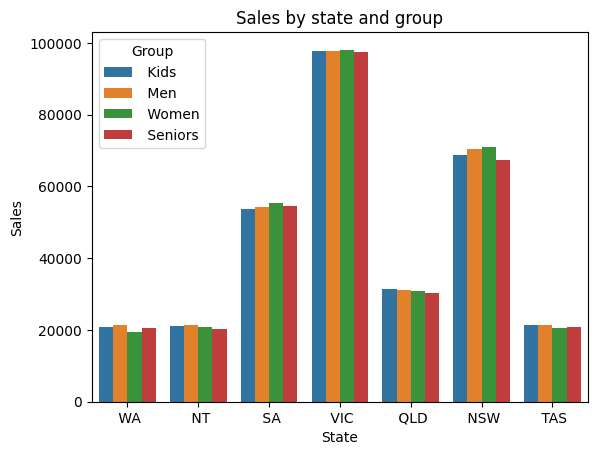

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import ticker
sns.barplot(data=df, x='State', y='Sales', hue='Group', errorbar=None)
plt.title('Sales by state and group')
plt.show()


VIC had the highest sales, followed by NSW then SA, and then QLD, TAS, NT, and WA had the lowest sales. Spending was relatively consistent throughout each group.

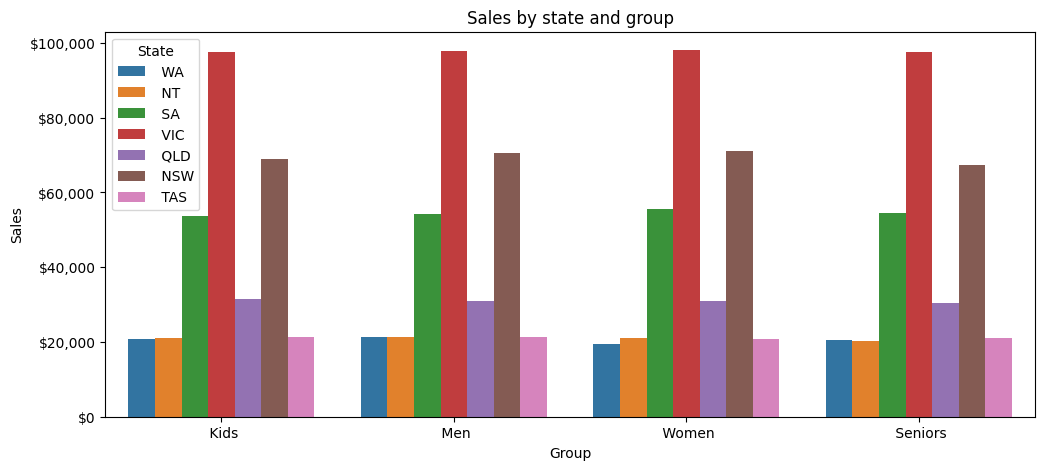

In [18]:
plt.figure(figsize=(12, 5))
ax = sns.barplot(data=df, x='Group', y='Sales', hue='State', errorbar=None)

# Format dollars
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'${x:,.0f}')
)

plt.title('Sales by state and group')
plt.show()


Similarly to the previous graph, sales by state vary, with VIC having the highest and WA, NT, and NAS having the lowest. All groups seem to spend about the same within each state.

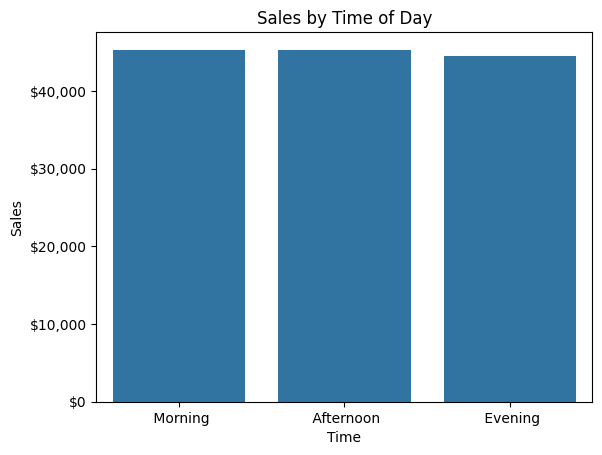

In [19]:
ax = sns.barplot(data=df, x='Time', y='Sales', errorbar=None, order=[' Morning', ' Afternoon', ' Evening'])
plt.title('Sales by Time of Day')

# Format dollars
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'${x:,.0f}')
)

plt.show()

All times of the day have very similar total sales, with evening being slightly less.

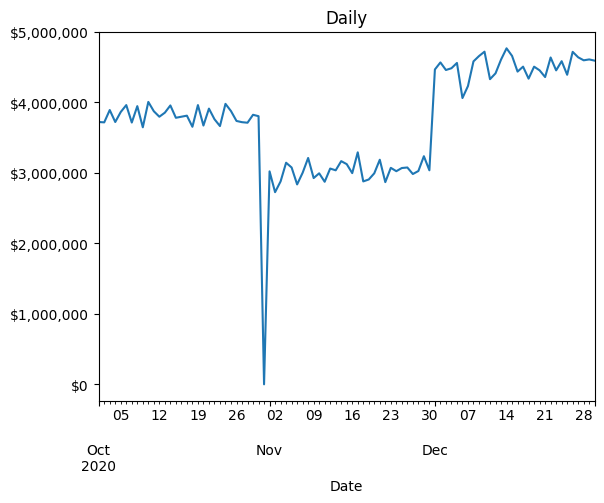

In [20]:
df['Date'] = pd.to_datetime(df['Date'])
time_df = df.set_index('Date')
daily = time_df['Sales'].resample('D').sum()
ax = daily.plot(title='Daily')

# Format dollars
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'${x:,.0f}')
)


In November, sales volume dropped, and then went up in December. 

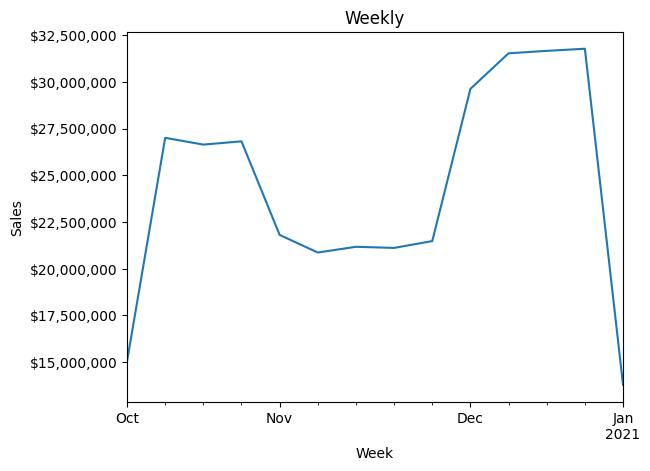

In [21]:
monthly = time_df['Sales'].resample('W').sum()
ax = monthly.plot(title='Weekly')

# Format dollars
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'${x:,.0f}')
)

ax.set_ylabel('Sales')
ax.set_xlabel('Week')
plt.show()

Similarly to the daily chart, we see that October had sales around $27 million, then in November, sales were consistently around $21 million, and in December it went up to around $31 million.

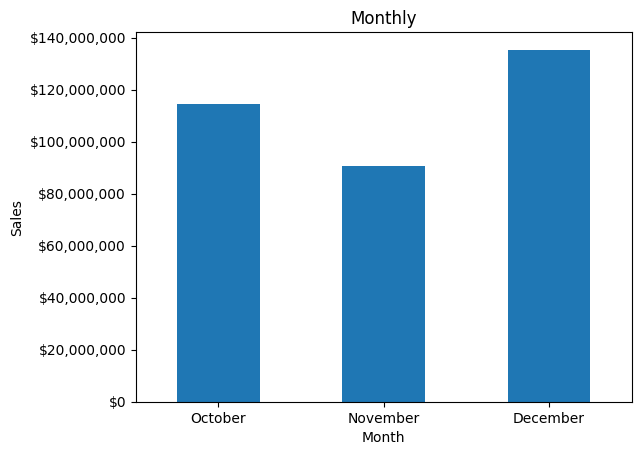

In [22]:
monthly = time_df['Sales'].resample('ME').sum()
ax = monthly.plot(kind='bar', title='Monthly')
ax.set_xticklabels(['October', 'November', 'December'], rotation=0)
ax.set_xlabel('Month')
ax.set_ylabel('Sales')

# Format dollars
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'${x:,.0f}')
)

plt.show()

December had the highest sales, so it may be the best time to run promotions.

*   Include your recommendation and indicate why you are choosing the recommended visualization package.

Seaborn has the tools necessary to create the dashboards and it requires minimal syntax.

## 4. Report generation

*   Use JupyterLab Notebook for generating reports, which includes tasks such as data wrangling, analysis, and visualization. 

*   Use Markdown in suitable places while presenting your report.

*   Use suitable graphs, plots, and analysis reports in the report, along with recommendations. Note that various aspects of analysis require different graphs and plots.
    *   Use a box plot for descriptive statistics.
    *   Use the Seaborn distribution plot for any other statistical plotting.

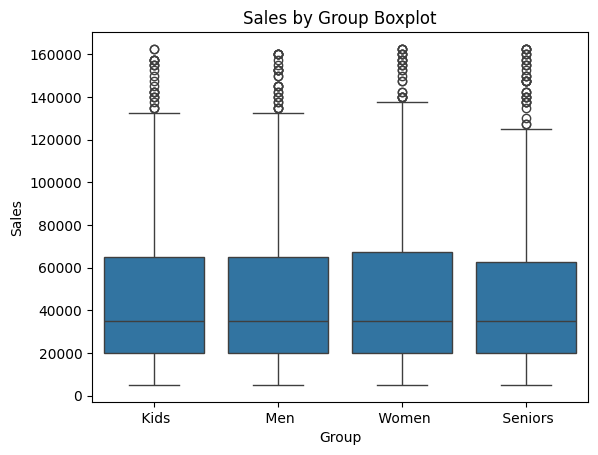

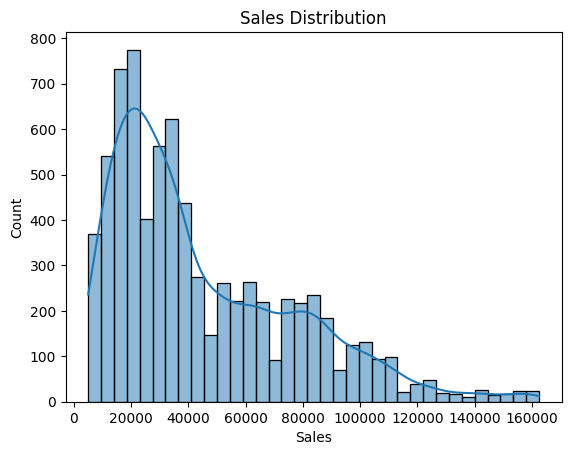

In [23]:
# Box and Dist plots
sns.boxplot(data=df, x='Group', y='Sales')
plt.title('Sales by Group Boxplot')
plt.show()

sns.histplot(df['Sales'], kde=True)
plt.title('Sales Distribution')
plt.show()